In [1]:
import numpy as np
import matplotlib.pyplot as plt

from phase import PhaseSolver, PhaseConfig

def correct(frame, mask):
    ys, xs = np.where(mask)
    corr = frame.astype(float).copy()
    for y, x in zip(ys, xs):
        nb  = frame[max(0,y-1):y+2, max(0,x-1):x+2]
        nbm = mask [max(0,y-1):y+2, max(0,x-1):x+2]
        good = nb[~nbm]
        if good.size: corr[y,x] = np.median(good)
    return corr

N = 20

In [25]:
# Read dark frames
data_dark = np.load("../../data/dark_400_20260907_134803.npz")
stack_dark = data_dark['stack'][0]

In [26]:
# Find and correct for hot pixels
frames = stack_dark            # (N,H,W), same gain+exposure as your data

m = frames.mean(0)                 # per-pixel mean  -> high dark current
s = frames.std(0)                  # per-pixel std   -> RTS/flicker

def rob(x, k=5):                   # robust threshold, unbiased by outliers
    med = np.median(x)
    mad = np.median(np.abs(x-med))*1.4826
    return np.abs(x-med) >= k*mad

mask = rob(m) | rob(s)             # (H,W) bool, True = hot
print(100*mask.mean(), "% hot")

stack_dark_corr = np.stack([correct(stack_dark[n], mask) for n in range(len(stack_dark))])
stack_dark_ref = stack_dark_corr.mean(axis=0)

0.0750137741046832 % hot


In [27]:
# Read ref bright frames
data_ref_bright = np.load("../../data/piezo_ref_bright_400_20260907_134514.npz")
stack_ref_bright = data_ref_bright['stack'][0][:N]

In [28]:
# Read ref bright frames
data_sample_bright = np.load("../../data/piezo_sample_bright_400_20260907_135149.npz")
stack_sample_bright = data_sample_bright['stack'][0][:N]

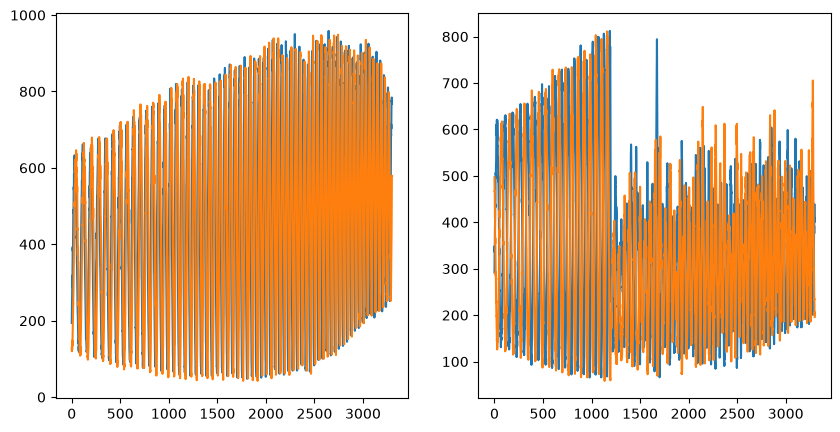

In [29]:
# Correct for hot pixels and subtract dark
stack_ref_bright_corr = np.stack([correct(stack_ref_bright[n], mask) for n in range(len(stack_ref_bright))])
stack_ref_bright_corr = np.maximum(stack_ref_bright_corr - stack_dark_ref, 0)

stack_sample_bright_corr = np.stack([correct(stack_sample_bright[n], mask) for n in range(len(stack_ref_bright))])
stack_sample_bright_corr = np.maximum(stack_sample_bright_corr - stack_dark_ref, 0)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(stack_ref_bright_corr[0,1000])
plt.plot(stack_ref_bright_corr[3,1000])

plt.subplot(122)
plt.plot(stack_sample_bright_corr[0,1000])
plt.plot(stack_sample_bright_corr[3,1000])

In [30]:
# Compute noise
sigma_ref_n = np.sqrt(stack_ref_bright_corr*2.6596) / 2.6596    # (N,P), gain=100
sigma_ref_pixel = np.sqrt((sigma_ref_n**2).mean(0))          # (P,)

rms_ref_bright = np.sqrt((sigma_ref_pixel**2).mean())
noise_floor_ref_bright = np.sqrt((sigma_ref_pixel**2).mean()) / stack_ref_bright_corr.std()

print(f"RMS noise ref: {rms_ref_bright}")
print(f"Noise floor ref: {noise_floor_ref_bright}")

sigma_sample_n = np.sqrt(stack_sample_bright_corr*2.6596) / 2.6596    # (N,P), gain=100
sigma_sample_pixel = np.sqrt((sigma_sample_n**2).mean(0))          # (P,)

rms_sample_bright = np.sqrt((sigma_sample_pixel**2).mean())
noise_floor_sample_bright = np.sqrt((sigma_sample_pixel**2).mean()) / stack_sample_bright_corr.std()

print(f"RMS noise sample: {rms_sample_bright}")
print(f"Noise floor sample: {noise_floor_sample_bright}")

RMS noise ref: 12.976838827607322
Noise floor ref: 0.056726163422899725
RMS noise sample: 11.875078831085956
Noise floor sample: 0.061194304980116215


In [ ]:
iters = 30
tol = 1e-4
refine_iters = 10
refine_tol = 1e-4
degree = 2

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = True
cfg_d.gain_mode = "joint"
cfg_d.precise_reduce = False
cfg_d.method = "aia_step_field"
cfg_d.method_kwargs = {'iters': iters, "tol": tol, 
                       "refine_iters": refine_iters, 'refine_tol': refine_tol,
                       "degree": degree}
cfg_d.phi_error_simplified = True
#cfg_d.noise_std = sigma_sample_pixel

solver_d = PhaseSolver(cfg_d)
solver_d.fit(stack_sample_bright_corr)

mp = solver_d.method_param_
phi_error = solver_d.phi_error_
print(f"Converged: {mp.refine_converged}")
print(f"AIA converged: {mp.aia_param.converged}")
print(f"Reconstruction error: {solver_d.reconstruction_error_}")
print(f"Phi error: {np.sqrt(np.mean(phi_error**2))*180/np.pi}")
print(f"Base AIA error: {mp.aia_param.predicted_rms*180/np.pi}")

Converged: True
AIA converged: True
Reconstruction error: 11.871114286069208
Phi error: 1.2349775328246373
Base AIA error: 2.0724709556411494


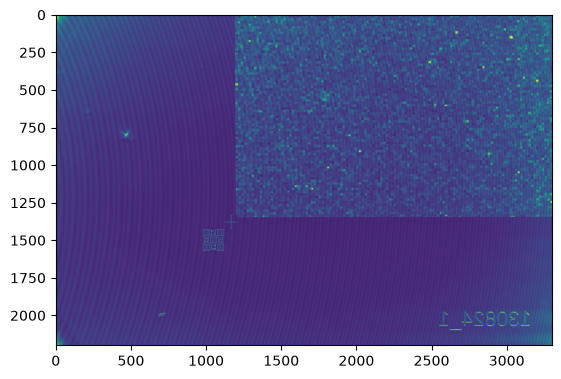

In [35]:
plt.imshow(phi_error)
plt.clim([0, 0.1])

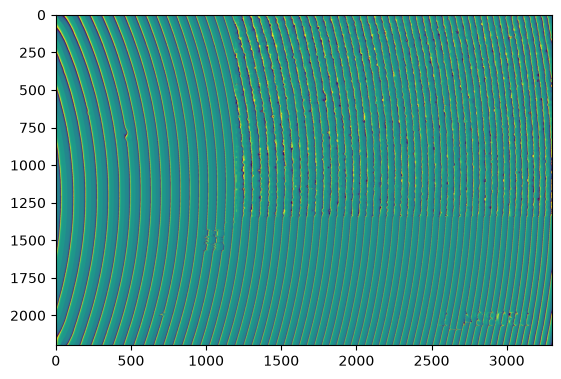

In [42]:
plt.imshow(phi_error/solver_d.phi_)
plt.clim([-0.1, 0.1])

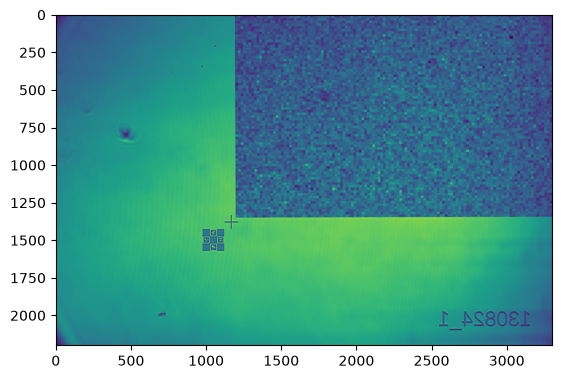

In [33]:
plt.imshow(solver_d.b_)